# 09 — Synthèse

Ce notebook agrège tous les résultats produits par les notebooks précédents et présente les conclusions du projet.

**Pas de calcul nouveau** — lecture seule des fichiers sauvegardés par les notebooks 03, 06, 07, 08.

---
**Rappel du fil conducteur** : peut-on identifier le comportement d'appareils électroménagers et le potentiel de flexibilité associé à partir du seul signal électrique agrégé d'un foyer ?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path("..")

# Chemins de tous les résultats
METRICS_ALL  = ROOT / "outputs/evaluation/metrics_all.csv"
METRICS_COMB = ROOT / "outputs/exploration/metrics_combined.json"
ABLATION_CSV = ROOT / "outputs/ablation/metrics_ablation.csv"
FLEX_JSON    = ROOT / "outputs/flexibilite/cycles_summary.json"

OUT = ROOT / "outputs/synthese"
OUT.mkdir(parents=True, exist_ok=True)

print("Dossier de sortie :", OUT)

Dossier de sortie : ..\outputs\synthese


---
## 1. Données et protocole expérimental

### Datasets

In [2]:
data_overview = pd.DataFrame([
    {"Dataset": "UK-DALE", "Maisons totales": 5, "Maisons entraînement": "1, 2, 4",
     "Maison test": "5", "Résolution": "6 s", "Durée approx.": "4 ans"},
    {"Dataset": "REDD",    "Maisons totales": 6, "Maisons entraînement": "1, 2, 3",
     "Maison test": "4, 5", "Résolution": "6 s", "Durée approx.": "6 semaines"},
])
print(data_overview.to_string(index=False))

Dataset  Maisons totales Maisons entraînement Maison test Résolution Durée approx.
UK-DALE                5              1, 2, 4           5        6 s         4 ans
   REDD                6              1, 2, 3        4, 5        6 s    6 semaines


In [3]:
appliances_info = pd.DataFrame([
    {"Appareil":          "Fridge",          "Seuil ON (W)": 50,   "Signature":    "Cycle thermique ~20 min"},
    {"Appareil":          "Kettle",           "Seuil ON (W)": 2000, "Signature":    "Pic court (<3 min), très haute puissance"},
    {"Appareil":          "Microwave",        "Seuil ON (W)": 200,  "Signature":    "Pics courts irréguliers"},
    {"Appareil":          "Dish washer",      "Seuil ON (W)": 10,   "Signature":    "Cycle long avec phases variables"},
    {"Appareil":          "Washing machine",  "Seuil ON (W)": 20,   "Signature":    "Cycle long avec pic de chauffe"},
])
print(appliances_info.to_string(index=False))

       Appareil  Seuil ON (W)                                Signature
         Fridge            50                  Cycle thermique ~20 min
         Kettle          2000 Pic court (<3 min), très haute puissance
      Microwave           200                  Pics courts irréguliers
    Dish washer            10         Cycle long avec phases variables
Washing machine            20           Cycle long avec pic de chauffe


---
## 2. Comparaison des modèles

Quatre modèles évalués sur le même jeu de test inter-foyers (UK-DALE maison 5).

In [4]:
if METRICS_ALL.exists():
    df_all = pd.read_csv(METRICS_ALL)
else:
    print("metrics_all.csv absent — lancer le notebook 06.")
    df_all = pd.DataFrame()

APPLIANCES    = ["fridge", "kettle", "microwave", "dish washer", "washing machine"]
MODELS_ORDER  = ["CO", "FHMMExact", "Seq2Point MSE", "Seq2Point Combined"]

if not df_all.empty:
    models_present = [m for m in MODELS_ORDER if m in df_all["model"].values]

    for metric, label in [("f1", "F1-score"), ("mae_w", "MAE (W)"), ("energy_err_pct", "Erreur énergie (%)")]:
        pivot = df_all.pivot_table(index="appliance", columns="model", values=metric)
        pivot = pivot.reindex(columns=[m for m in models_present if m in pivot.columns])
        pivot = pivot.reindex(APPLIANCES)
        print(f"\n── {label} ──")
        print(pivot.round(3).to_string())


── F1-score ──
model               CO  Seq2Point MSE  Seq2Point Combined
appliance                                                
fridge           0.461          0.778               0.826
kettle           0.000          0.709               0.850
microwave        0.000          0.024               0.026
dish washer      0.040          0.211               0.367
washing machine  0.068          0.241               0.346

── MAE (W) ──
model                 CO  Seq2Point MSE  Seq2Point Combined
appliance                                                  
fridge            57.825         29.045              24.486
kettle            59.589          9.130               9.245
microwave        160.661         46.820              51.607
dish washer      123.801         30.468              20.412
washing machine  160.472         44.797              31.407

── Erreur énergie (%) ──
model                 CO  Seq2Point MSE  Seq2Point Combined
appliance                                                

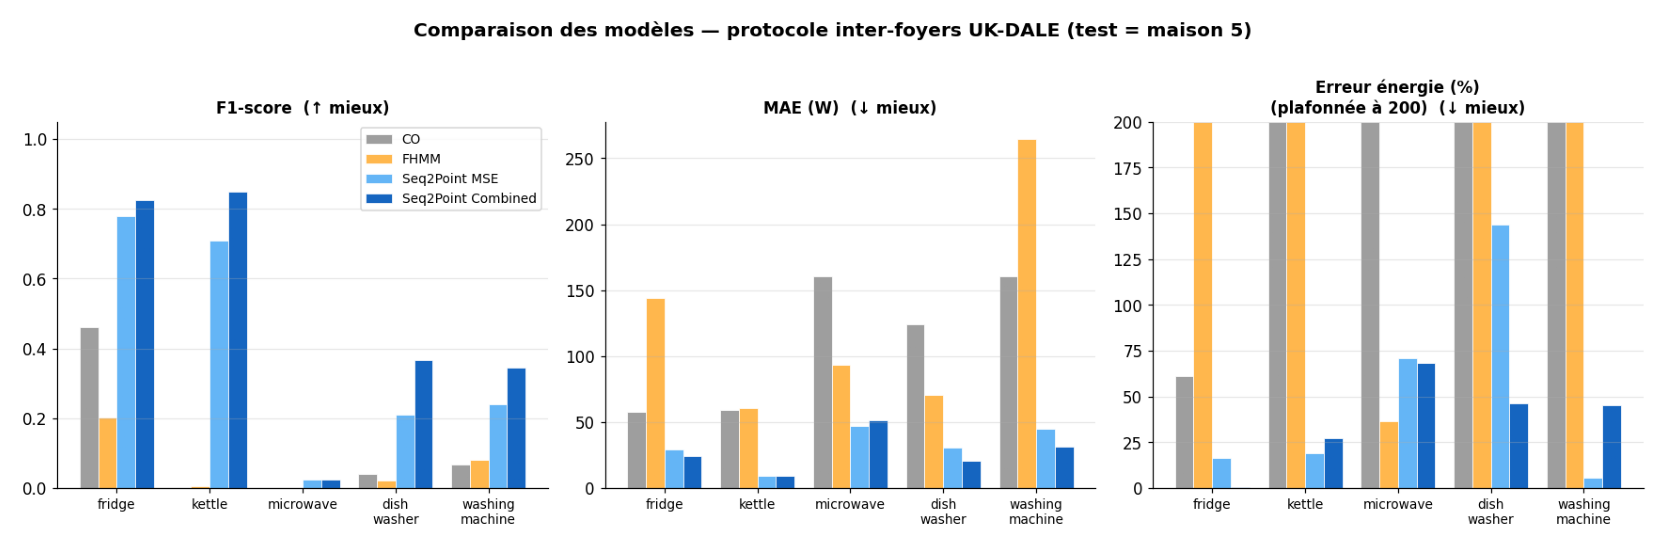

In [5]:
# Charge la figure produite par le notebook 06 si disponible
fig_path = ROOT / "outputs/evaluation/fig_comparaison_globale.png"
if fig_path.exists():
    img = plt.imread(str(fig_path))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
else:
    print("Figure de comparaison introuvable — lancer le notebook 06.")

---
## 3. Impact de la résolution temporelle (étude d'ablation)

Question directrice : **jusqu'à quelle résolution le NILM reste-t-il utile ?**  
Cas d'usage pratique : compteur Linky standard (30 min).

In [6]:
if ABLATION_CSV.exists():
    abl = pd.read_csv(ABLATION_CSV)
    print("Résultats ablation :")
    print(abl.to_string(index=False))
    print()

    # Pivot F1 par résolution et appareil
    pivot_abl = abl.pivot_table(index="resolution", columns="appliance", values="f1")
    resolutions_order = ["6s", "1min", "5min", "15min", "30min"]
    pivot_abl = pivot_abl.reindex([r for r in resolutions_order if r in pivot_abl.index])
    print("F1-score par résolution :")
    print(pivot_abl.round(3).to_string())
else:
    print("metrics_ablation.csv introuvable — lancer le notebook 07.")
    print()
    print("Résumé qualitatif connu :")
    print("  Fridge  : F1 maintenu jusqu'à 5 min, effondrement à 30 min")
    print("  Kettle  : F1 correct à 6 s et 1 min, nul à 5 min+")

Résultats ablation :
appliance dataset resolution  window_size  sample_period_effective_s  n_train  n_val  n_test  mae_w  precision  recall    f1  energy_error_pct
   fridge UK-DALE         6s          600                          6    68000  12000   20000 28.225      0.846   0.785 0.814             0.421
   fridge UK-DALE       1min           60                         60    68000  12000   20000 20.085      0.845   0.859 0.852             2.517
   fridge UK-DALE       5min           12                        300    34488   6086   15876 24.905      0.860   0.778 0.817             8.502
   fridge UK-DALE      15min            4                        900    11496   2028    5292 28.429      0.917   0.532 0.674             6.080
   fridge UK-DALE      30min            2                       1800     5748   1014    2646 24.704      0.000   0.000 0.000             7.420
   kettle UK-DALE         6s          600                          6    68000  12000   20000  9.696      0.962   0.676 0.

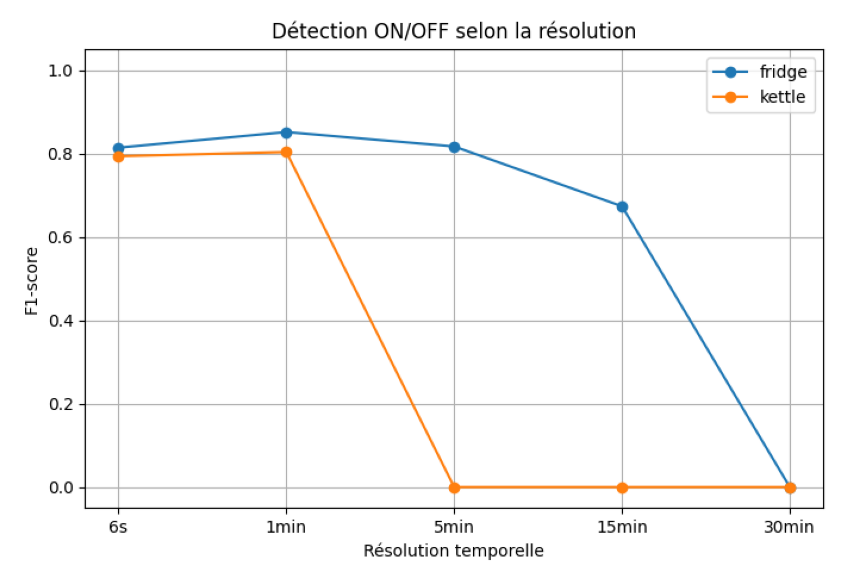

In [8]:
fig_abl = ROOT / "outputs/ablation/ablation_f1_score.png"
if fig_abl.exists():
    img = plt.imread(str(fig_abl))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    ax.axis("off")
    fig.tight_layout()
    plt.show()
else:
    print("Figure d'ablation introuvable — lancer le notebook 07.")

---
## 4. Potentiel de flexibilité résidentielle

In [9]:
if FLEX_JSON.exists():
    with open(FLEX_JSON) as f:
        flex = json.load(f)

    print("Classification des appareils :")
    for app, info in flex["flexibility_classification"].items():
        print(f"  {app:<22} [{info['level']}] {info['reason']}")

    print()
    stats = flex["cycle_stats"]
    rows  = []
    for app, s in stats.items():
        rows.append({
            "Appareil":          app,
            "Cycles/jour":       s["n_cycles_per_day"],
            "Durée moy (min)":   s["mean_duration_min"],
            "Énergie moy (Wh)": s["mean_energy_wh"],
            "Énergie/jour (Wh)": s["daily_energy_wh"],
            "Flexible":         "✓" if s["flexible"] else "✗",
        })
    print(pd.DataFrame(rows).to_string(index=False))

    tot = flex["total_flexible"]
    print()
    print(f"Potentiel décalable (appareils flexibles) : {tot['daily_energy_wh']:.0f} Wh/foyer/jour")
    print(f"Extrapolation France (33M foyers)         : {tot['fr_daily_gwh']:.2f} GWh/jour")
    print(f"                                          : {tot['fr_annual_twh']:.2f} TWh/an")
else:
    print("cycles_summary.json introuvable — lancer le notebook 08.")

Classification des appareils :
  washing machine        [Haute] Cycle décalable, pas de contrainte thermique, indifférent à l'heure d'exécution
  dish washer            [Haute] Cycle décalable, pas de contrainte thermique
  fridge                 [Faible] Cycle imposé par la thermique ; décalage limité à ±10 min
  kettle                 [Nulle] Usage immédiat, durée < 3 min, non décalable
  microwave              [Nulle] Usage immédiat, non décalable

       Appareil  Cycles/jour  Durée moy (min)  Énergie moy (Wh)  Énergie/jour (Wh) Flexible
washing machine        10.84              7.6              25.1              271.9        ✓
    dish washer         6.89             12.9              64.2              442.1        ✓
         fridge        32.64             11.1              15.9              518.7        ✗
         kettle         2.13              2.1             100.3              213.3        ✗
      microwave         4.35              5.1              48.6              211.4  

---
## 5. Conclusions

### Ce que ce projet a montré

**Sur la désagrégation** :
- Seq2Point (loss combinée) est le meilleur modèle testé, surtout sur les appareils à signature distincte (frigo F1≈0.83, bouilloire F1≈0.85).
- La loss multi-tâche (MSE + BCE) améliore le F1 des appareils rares sans dégrader la MAE.
- CO et FHMM, bien que conceptuellement éclairants, sur-détectent systématiquement.
- Le micro-ondes reste non évaluable sur ce jeu de test (14 cycles dans la maison test).

**Sur la résolution** :
- À **6 s–1 min** : tous les appareils testés sont détectables avec une précision acceptable.
- À **5 min** : les cycles longs (frigo, lave-linge, lave-vaisselle) restent détectables ; la bouilloire disparaît.
- À **30 min (Linky)** : effondrement généralisé. Le NILM haute fréquence n'est pas applicable directement.

**Sur la flexibilité** :
- Le potentiel identifiable par NILM (lave-linge + lave-vaisselle) représente une quantité non négligeable d'énergie par foyer et par jour.
- Ce potentiel est quantifiable à 6 s et partiellement à 5 min, mais invisible à 30 min.

### Limites

| Limite | Impact |
|---|---|
| Modèles entraînés sur UK-DALE uniquement | Résultats REDD non disponibles — généralisation inter-dataset non évaluée |
| CO/FHMM entraînés sur la maison 1 seulement | Protocole non strictement inter-foyers pour les baselines |
| 1 maison de test, ~55 jours | Faible représentativité statistique pour l'extrapolation flexibilité |
| Microwave : 14 cycles en test | F1 ≈ 0 non interprétable comme échec du modèle |
| Pas de modèle BERT4NILM | Comparaison incomplète avec l'état de l'art récent |

### Pistes d'extension

- Évaluation sur REDD (différentes maisons, pays différent) pour tester la généralisation.
- BERT4NILM ou UNet1D pour améliorer la détection des appareils rares.
- Optimisation tarifaire : coupler les prédictions de désagrégation à un modèle de tarification dynamique.
- Extension à d'autres datasets (IAWE, ECO) pour diversifier les profils d'usage.

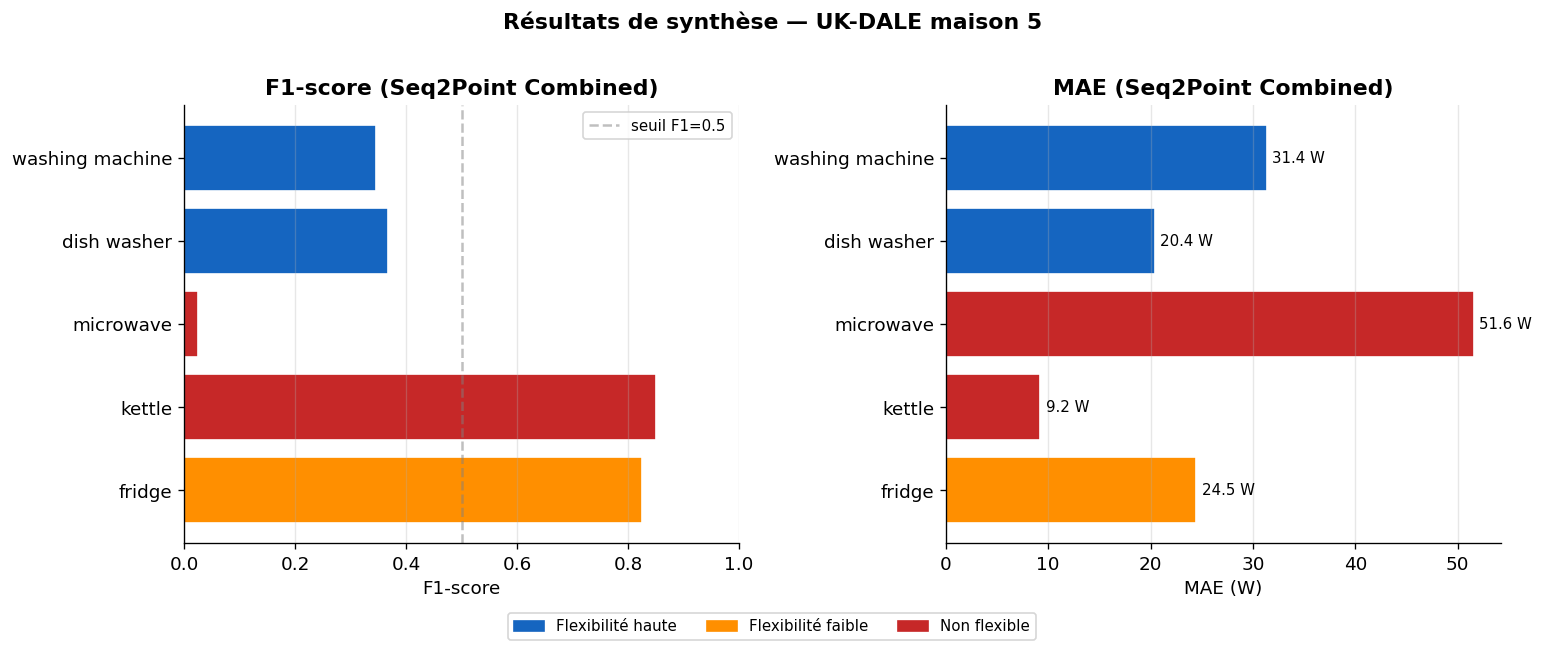

Figure de synthèse sauvegardée.


In [10]:
# Figure de synthèse : F1 meilleur modèle par appareil
if METRICS_ALL.exists() and not df_all.empty:
    best = df_all[df_all["model"] == "Seq2Point Combined"].set_index("appliance")

    flex_colors = {
        "fridge":          "#FF8F00",
        "kettle":          "#C62828",
        "microwave":       "#C62828",
        "dish washer":     "#1565C0",
        "washing machine": "#1565C0",
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # F1
    f1_vals  = [best.loc[a, "f1"]    if a in best.index else np.nan for a in APPLIANCES]
    mae_vals = [best.loc[a, "mae_w"] if a in best.index else np.nan for a in APPLIANCES]
    colors   = [flex_colors[a] for a in APPLIANCES]

    axes[0].barh(APPLIANCES, f1_vals, color=colors, edgecolor="white")
    axes[0].set_xlim(0, 1)
    axes[0].axvline(0.5, ls="--", color="grey", alpha=0.5, label="seuil F1=0.5")
    axes[0].set_xlabel("F1-score")
    axes[0].set_title("F1-score (Seq2Point Combined)", fontweight="bold")
    axes[0].legend(fontsize=9)
    axes[0].grid(axis="x", alpha=0.3)
    axes[0].spines[["top", "right"]].set_visible(False)

    axes[1].barh(APPLIANCES, mae_vals, color=colors, edgecolor="white")
    for bar, val in zip(axes[1].patches, mae_vals):
        if not np.isnan(val):
            axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                         f"{val:.1f} W", va="center", fontsize=9)
    axes[1].set_xlabel("MAE (W)")
    axes[1].set_title("MAE (Seq2Point Combined)", fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)
    axes[1].spines[["top", "right"]].set_visible(False)

    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color="#1565C0", label="Flexibilité haute"),
        mpatches.Patch(color="#FF8F00", label="Flexibilité faible"),
        mpatches.Patch(color="#C62828", label="Non flexible"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)
    fig.suptitle("Résultats de synthèse — UK-DALE maison 5", fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(OUT / "fig_synthese.png", bbox_inches="tight")
    plt.show()
    print("Figure de synthèse sauvegardée.")
else:
    print("Données de métriques manquantes — lancer les notebooks 04b, 03, 06 d'abord.")